In [1]:
%cd ..
from app.conf.run import build_interpretability_run_config
from app.data_providers import full_dataset
from processing.helpers import shot_accuracy_by_fields
%cd notebooks

/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions
/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions/notebooks


In [2]:
%cd ..

df = full_dataset()
%cd notebooks

/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions


Repo card metadata block was not found. Setting CardData to empty.


/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions/notebooks


       PLAYER_NAME  years_experience  SHOT_MADE_FLAG
0    Anthony Davis                -1        0.577358
1    Anthony Davis                 0        0.583333
2    Anthony Davis                 1        0.616097
3    Anthony Davis                 2        0.583333
4    Anthony Davis                 3        0.581945
..             ...               ...             ...
331    Tony Parker                13        0.528462
332    Tony Parker                14        0.508651
333    Tony Parker                15        0.532110
334    Tony Parker                16        0.487805
335    Tony Parker                17        0.547826

[336 rows x 3 columns]


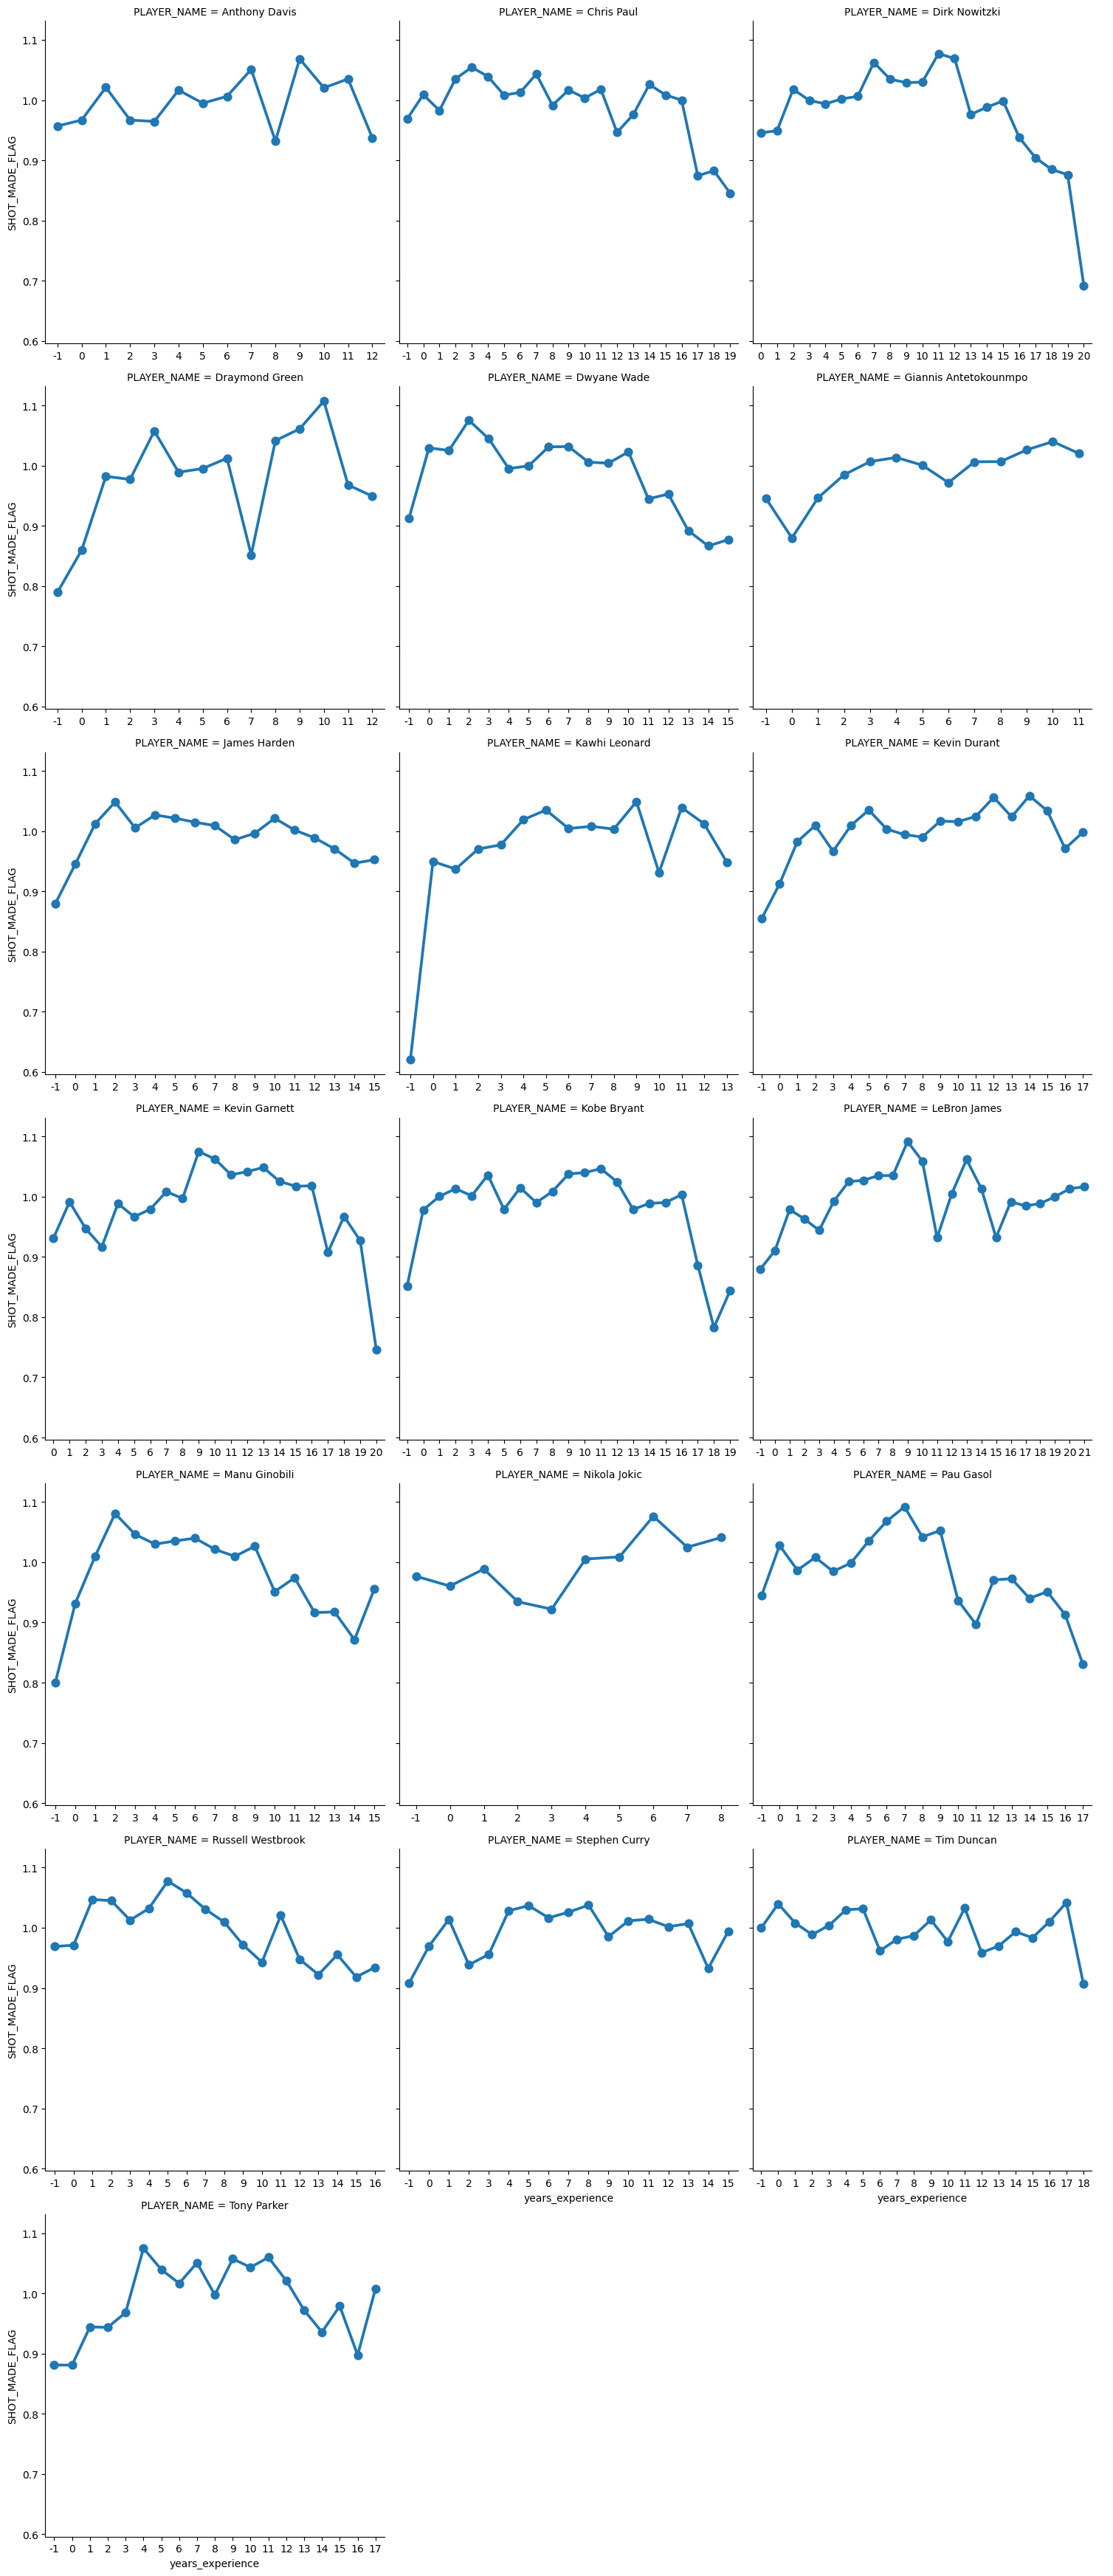

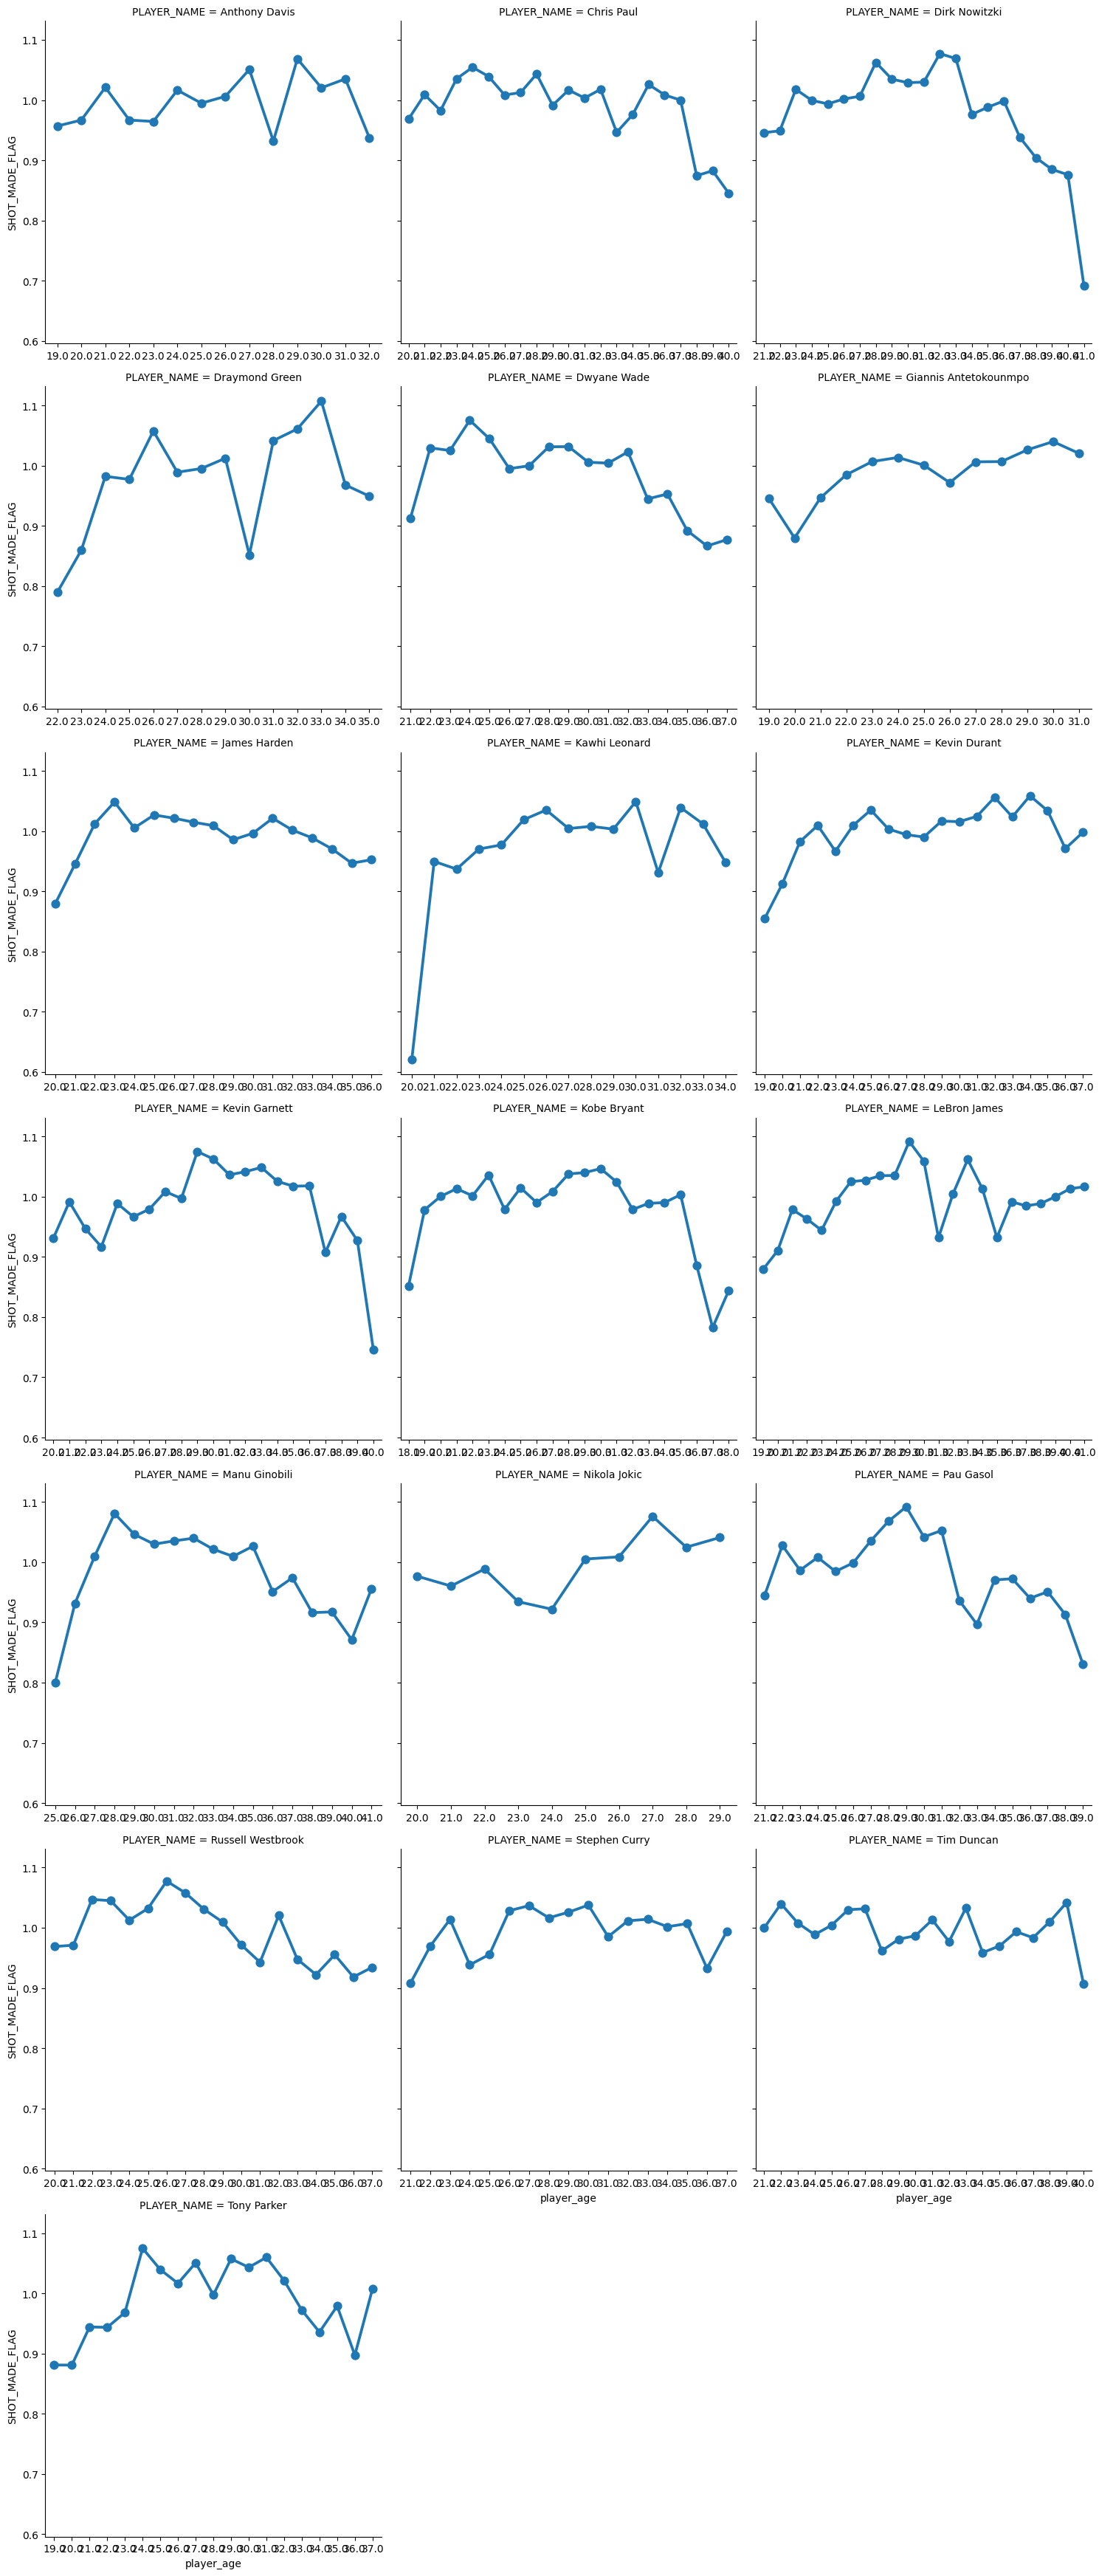

In [3]:
df_accuracy = shot_accuracy_by_fields(df,['PLAYER_NAME']).unstack()
df_accuracy_by_years = shot_accuracy_by_fields(df, ['PLAYER_NAME', 'years_experience']).reset_index()
df_accuracy_by_age = shot_accuracy_by_fields(df, ['PLAYER_NAME', 'player_age']).reset_index()

print(df_accuracy_by_years)


import numpy as np
import seaborn as sns

# for _,name in df_accuracy.index:
#     avg_accuracy = df_accuracy.loc[("SHOT_MADE_FLAG",name)]
#     years = df_accuracy_by_years[df_accuracy_by_years['PLAYER_NAME'] == name]['years_experience'].unique()
#     for year in years:
#         conditions = (
#             df_accuracy_by_years[(df_accuracy_by_years['PLAYER_NAME'] == name) & 
#             (df_accuracy_by_years['years_experience'] == year)]
#         )
#         if np.isnan(df_accuracy_by_years.loc[conditions, "SHOT_MADE_FLAG"]):
#             df_accuracy_by_years.loc[conditions, "SHOT_MADE_FLAG"] = avg_accuracy
#         df_accuracy_by_years.loc[conditions, "SHOT_MADE_FLAG"] /= avg_accuracy

def apply_avg(row):
    avg_accuracy = df_accuracy.loc[("SHOT_MADE_FLAG",row['PLAYER_NAME'])]
    
    if np.isnan(row["SHOT_MADE_FLAG"]):
        row["SHOT_MADE_FLAG"] = avg_accuracy
    row["SHOT_MADE_FLAG"] /= avg_accuracy
    return row
        
#df_accuracy_by_years = df_accuracy_by_years.unstack()
df_accuracy_by_years = df_accuracy_by_years.apply(apply_avg, axis=1)
df_accuracy_by_age = df_accuracy_by_age.apply(apply_avg, axis=1)
sns.catplot(data=df_accuracy_by_years, x="years_experience", y="SHOT_MADE_FLAG", col="PLAYER_NAME", kind="point", col_wrap=3, sharex=False)
sns.catplot(data=df_accuracy_by_age, x="player_age", y="SHOT_MADE_FLAG", col="PLAYER_NAME", kind="point", col_wrap=3, sharex=False)

In [4]:
for _,name in df_accuracy.index:
    print(name, df_accuracy_by_age.loc[df_accuracy_by_age[df_accuracy_by_age['PLAYER_NAME'] == name]["SHOT_MADE_FLAG"].argmax()]['player_age'])

Anthony Davis 29.0
Chris Paul 23.0
Dirk Nowitzki 30.0
Draymond Green 30.0
Dwyane Wade 22.0
Giannis Antetokounmpo 30.0
James Harden 22.0
Kawhi Leonard 29.0
Kevin Durant 21.0
Kevin Garnett 28.0
Kobe Bryant 31.0
LeBron James 29.0
Manu Ginobili 22.0
Nikola Jokic 26.0
Pau Gasol 27.0
Russell Westbrook 25.0
Stephen Curry 28.0
Tim Duncan 24.0
Tony Parker 24.0
